# 05b · Where the false positives come from, and training against them

Notebook 05 showed that gating the output does not fix Seq2Point's main error, false
washing-machine power in an unseen home. This notebook (1) diagnoses *where* that false energy
comes from on the validation house, (2) checks two cheap remedies that need no retraining, and
(3) tests one change aimed at the cause.

Everything here uses the validation house (18) only. The test homes stay untouched until
notebook 06.

| | |
|---|---|
| **Input** | Seq2Point checkpoints from notebook 04; training homes' sub-meter channels (training period only) |
| **Output** | checkpoints `artifacts/models/m4_*`, `artifacts/tables/nb05b_*`, `artifacts/metrics/nb05b_summary.json` |
| **Run time** | about 30 minutes on one laptop GPU |

In [1]:
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from refit_nilm import augment as A
from refit_nilm import cycles, io, metrics, plots
from refit_nilm import config as C
from refit_nilm import datasets as D
from refit_nilm import train as T

warnings.filterwarnings("ignore", category=FutureWarning)
plots.setup()
pd.set_option("display.width", 170, "display.max_columns", 30)
P = plots.PALETTE
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
W = int(json.load(open(C.METRIC_DIR / "nb04_summary.json"))["window_selection"]["chosen_window"])
houses = C.TRAIN_HOUSES + [C.VAL_HOUSE]
frames = {h: f for h, f in D.prepare([W], houses=houses)[0].items()}
spec = D.SplitSpec(test_houses=[])
labels = D.assign_splits(frames, spec, W)
cp = D.build_corpus(frames, labels, W)
st = D.standardisation(cp)
src = T.WindowSource(cp, st, DEVICE)
VS = cp.starts["val"]
H = C.VAL_HOUSE
y_val = D.to_series(cp, VS, cp.wm[VS + W // 2], H)
SUMMARY: dict = {"window": W}
KEYS = ["mae_w", "nde", "sae", "epd_wh", "f1", "precision", "recall", "cycle_f1", "cycle_recall", "cycle_precision", "overlap_pct", "extra_pct"]


def val_series(model) -> pd.Series:
    return D.to_series(cp, VS, T.predict(model, src, VS, st)["power"], H)


def row(name: str, p: pd.Series) -> dict:
    r = metrics.all_metrics(y_val, p)
    return {"model": name, **{k: r[k] for k in KEYS}}


m2 = {}
for s in C.SEEDS:
    model, _, _ = T.load_run(C.MODEL_DIR / f"m2_seq2point_w{W}_s{s}.pt", DEVICE)
    m2[s] = val_series(model)
    del model

## 1. Diagnosis: which appliance is running when Seq2Point predicts false power?

For every validation minute where the prediction exceeds the truth by more than 20 W, I look
up House 18's other plug monitors and attribute the false energy to the one drawing the most
power (if none draws more than 100 W, to unmetered load). Prediction = mean of the three seeds.

In [2]:
amap = io.parse_appliance_map(C.DATA_DIR / "CLEAN_READ_ME_081116.txt")
raw = io.load_clean_minutes(H)
names = {f"Appliance{c}": d.split(",")[0] for c, d in amap[H].items()}
wm_col = f"Appliance{io.washing_machine_channels(amap)[H][0]}"
others = [c for c in names if c != wm_col]
ens2 = sum(m2.values()) / len(m2)
fp = (ens2 - y_val.fillna(0)).clip(lower=0).dropna()
fp = fp[fp > 20]
o = raw.loc[fp.index, others]
lead = o.idxmax(axis=1).where(o.max(axis=1) > 100, "unmetered")
attrib = (fp.groupby(lead.map(lambda c: names.get(c, c))).sum() / fp.sum() * 100).sort_values(ascending=False).round(1)
attrib.to_frame("% of false energy").to_csv(C.TABLE_DIR / "nb05b_false_energy_attribution_val.csv")
SUMMARY["false_energy_attribution_val_pct"] = attrib.to_dict()
print(f"false energy {fp.sum() / 60_000:.1f} kWh vs true WM energy {y_val.sum() / 60_000:.1f} kWh")
attrib.to_frame("% of false energy")

false energy 22.0 kWh vs true WM energy 35.7 kWh


,% of false energy
Dishwasher,48.200001
Fridge-Freezer,18.200001
Freezer(garage),18.000000
unmetered,5.700000
Microwave,3.100000
Washer Dryer(garage),2.700000
Fridge(garage),1.600000
Television Site,1.300000
Desktop Computer,1.200000


**Reading.** The dishwasher is the main culprit: it also heats water at about 2 kW and runs
a multi-phase programme of similar length, so its aggregate signature is close to a wash. The
fridge-freezer and freezers appear because they are the largest load during *quiet* minutes:
that share is low-level "ghost" power the model spreads over ordinary background load. The
garage washer-dryer, which I expected to dominate, contributes little.

## 2. Two remedies that need no retraining

* **Activation filter.** Apply the same cycle rule used for the labels to the prediction and
  set to zero any predicted power outside a predicted activation of ≥ 30 minutes. This removes
  ghost power and short false spikes.
* **Seed ensemble.** Average the three Seq2Point seeds; averaging reduces the variance that
  separately trained networks have on an unseen home.

In [3]:
def activation_filter(p: pd.Series) -> pd.Series:
    mask = cycles.activation_mask(p.fillna(0).to_numpy())
    return p.where(mask, 0.0).where(p.notna())


rows = []
for s, p in m2.items():
    rows += [row(f"M2 s{s}", p), row(f"M2 s{s} + activation filter", activation_filter(p))]
rows += [row("M2 seed ensemble", ens2), row("M2 seed ensemble + activation filter", activation_filter(ens2))]
remedies = pd.DataFrame(rows)
remedies.to_csv(C.TABLE_DIR / "nb05b_remedies_val.csv", index=False)
remedies.round(3)

,model,mae_w,nde,sae,epd_wh,f1,precision,recall,cycle_f1,cycle_recall,cycle_precision,overlap_pct,extra_pct
0,M2 s10,5.048,0.685,0.561,84.459,0.463,0.324,0.809,0.590,0.710,0.505,62.821,93.249
1,M2 s10 + activation filter,3.563,0.853,0.411,76.382,0.466,0.538,0.412,0.590,0.710,0.505,33.433,25.492
2,M2 s20,4.904,0.620,0.521,76.699,0.413,0.279,0.792,0.599,0.681,0.534,62.668,89.392
3,M2 s20 + activation filter,3.331,0.850,0.537,74.155,0.473,0.590,0.395,0.599,0.681,0.534,30.102,16.170
4,M2 s42,5.913,0.719,0.694,95.374,0.402,0.271,0.775,0.621,0.725,0.543,58.313,111.095
5,M2 s42 + activation filter,3.158,0.802,0.508,68.375,0.470,0.576,0.397,0.621,0.725,0.543,33.772,15.383
6,M2 seed ensemble,5.194,0.602,0.592,82.491,0.429,0.288,0.845,0.644,0.812,0.533,62.482,96.698
7,M2 seed ensemble + activation filter,2.992,0.757,0.465,62.869,0.522,0.575,0.478,0.644,0.812,0.533,38.083,15.403


**Reading.** The activation filter is a trade-off, not a fix: it cuts false energy from ~95 %
to ~15 % of the true energy and doubles minute-level precision, but it also deletes about half
of the *true* energy, because the predicted power inside a real cycle often dips below 20 W
and the surviving fragments are shorter than 30 minutes. It is useful when false alarms are
expensive (e.g. counting cycles) and harmful when energy totals matter. The seed ensemble
improves NDE and cycle F1 at no cost and is kept.

## 3. Training against the cause: distractor augmentation

**Design.** During training, with probability *p_distractor* a real activation of a
dishwasher, tumble dryer, washer-dryer or kettle is added to the input window and the target
is left unchanged; with probability *p_wm* a real washing-machine activation is added to both
input and target. The model therefore sees, many times over, "2 kW water heating that is not a
washing machine" in other homes' backgrounds. This is the synthetic-activation idea of Kelly &
Knottenbelt (2015) and Rafiq et al. (2021), pointed at the failure measured above.

**Leakage.** Activations come only from minutes labelled `train` (training period of the
training homes). Nothing from the seen-test period, the validation house or the test homes
enters the banks. Augmentation is applied only while training.

**Everything else is identical to M2** (architecture, W, optimiser, early stopping, seeds), so
any difference is due to the augmentation.

**Acceptance rule, fixed before training.** The augmented model (M4) is adopted only if its
three-seed mean on House 18 beats M2's three-seed mean by more than M2's seed standard
deviation on **both** NDE (by > 0.051) and cycle F1 (by > 0.016). Otherwise the result is
reported as inconclusive and M2 stays the reference.

In [4]:
distractors, wm_bank = A.build_banks(labels, C.TRAIN_HOUSES)
bank_tab = pd.Series({k: len(v) for k, v in distractors.items()} | {"washing machine": len(wm_bank)}, name="activations")
bank_tab.to_frame().to_csv(C.TABLE_DIR / "nb05b_activation_banks.csv")
SUMMARY["banks"] = bank_tab.to_dict()
bank_tab.to_frame()

,activations
dishwasher,4232
tumble dryer,1833
washer dryer,275
kettle,10941
washing machine,2284


In [5]:
m2_val = remedies[remedies.model.isin([f"M2 s{s}" for s in C.SEEDS])]
m2_mean, m2_std = m2_val[["nde", "cycle_f1"]].mean(), m2_val[["nde", "cycle_f1"]].std()
CONFIGS = {"distractors only": A.AugmentConfig(p_distractor=0.5, p_wm=0.0), "distractors + WM": A.AugmentConfig(p_distractor=0.5, p_wm=0.1)}
aug_rows, m4 = [], {}
for cname, acfg in CONFIGS.items():
    cfg = T.TrainConfig(model="seq2point", window=W, seed=42, augment=acfg.__dict__)
    aug = A.Augmenter(distractors, wm_bank, st, acfg, W, DEVICE, seed=42)
    model, hist = T.fit(cp, st, cfg, device=DEVICE, augmenter=aug)
    tag = "d" if acfg.p_wm == 0 else "dw"
    T.save_run(C.MODEL_DIR / f"m4_aug{tag}_w{W}_s42.pt", model, cfg, st, hist)
    p = val_series(model)
    aug_rows.append({**row(f"M4 {cname} s42", p), "config": cname, "seed": 42, "epochs": len(hist)})
    m4[(cname, 42)] = p
    del model
    torch.cuda.empty_cache()
cfg_tab = pd.DataFrame(aug_rows)
BEST = cfg_tab.sort_values("nde").iloc[0]["config"]
SUMMARY["config_selection_val_nde"] = dict(zip(cfg_tab["config"], cfg_tab["nde"]))
SUMMARY["chosen_config"] = BEST
cfg_tab[["model", "nde", "cycle_f1", "f1", "precision", "overlap_pct", "extra_pct", "epochs"]].round(3)

epoch  1  train_loss 0.6251  val_NDE 0.7749  val_MAE 7.49 W  (20s)


epoch  2  train_loss 0.4351  val_NDE 0.7324  val_MAE 7.39 W  (18s)


epoch  3  train_loss 0.3576  val_NDE 0.9108  val_MAE 8.92 W  (18s)


epoch  4  train_loss 0.3039  val_NDE 0.6933  val_MAE 6.10 W  (18s)


epoch  5  train_loss 0.2670  val_NDE 0.7464  val_MAE 6.84 W  (18s)


...

epoch  4  train_loss 0.5835  val_NDE 0.8468  val_MAE 13.81 W  (21s)


epoch  5  train_loss 0.5414  val_NDE 0.7030  val_MAE 9.08 W  (22s)


epoch  6  train_loss 0.5104  val_NDE 0.8482  val_MAE 9.53 W  (21s)


epoch  7  train_loss 0.4852  val_NDE 0.8055  val_MAE 8.65 W  (22s)


,model,nde,cycle_f1,f1,precision,overlap_pct,extra_pct,epochs
0,M4 distractors only s42,0.693,0.581,0.408,0.266,61.159,118.746,9
1,M4 distractors + WM s42,0.692,0.577,0.298,0.179,70.281,208.704,7


In [6]:
acfg = CONFIGS[BEST]
tag = "d" if acfg.p_wm == 0 else "dw"
for seed in [s for s in C.SEEDS if s != 42]:
    cfg = T.TrainConfig(model="seq2point", window=W, seed=seed, augment=acfg.__dict__)
    aug = A.Augmenter(distractors, wm_bank, st, acfg, W, DEVICE, seed=seed)
    model, hist = T.fit(cp, st, cfg, device=DEVICE, augmenter=aug)
    T.save_run(C.MODEL_DIR / f"m4_aug{tag}_w{W}_s{seed}.pt", model, cfg, st, hist)
    p = val_series(model)
    aug_rows.append({**row(f"M4 {BEST} s{seed}", p), "config": BEST, "seed": seed, "epochs": len(hist)})
    m4[(BEST, seed)] = p
    del model
    torch.cuda.empty_cache()

epoch  1  train_loss 1.1640  val_NDE 0.7622  val_MAE 18.39 W  (22s)


epoch  2  train_loss 0.7865  val_NDE 0.6204  val_MAE 6.89 W  (22s)


epoch  3  train_loss 0.6732  val_NDE 0.7399  val_MAE 9.65 W  (22s)


epoch  4  train_loss 0.6203  val_NDE 0.6461  val_MAE 8.68 W  (22s)


epoch  5  train_loss 0.5796  val_NDE 0.5407  val_MAE 5.66 W  (22s)


...

epoch  4  train_loss 0.6218  val_NDE 0.8518  val_MAE 11.47 W  (22s)


epoch  5  train_loss 0.5793  val_NDE 0.7484  val_MAE 10.02 W  (22s)


epoch  6  train_loss 0.5525  val_NDE 0.9879  val_MAE 12.38 W  (22s)


epoch  7  train_loss 0.5216  val_NDE 0.8011  val_MAE 9.37 W  (22s)


epoch  8  train_loss 0.5036  val_NDE 0.7548  val_MAE 9.16 W  (21s)


## 4. Decision

In [7]:
aug_tab = pd.DataFrame(aug_rows)
aug_tab.to_csv(C.TABLE_DIR / "nb05b_augmentation_val.csv", index=False)
m4_runs = aug_tab[aug_tab.config == BEST]
m4_mean = m4_runs[KEYS].mean()
ens4 = sum(m4[(BEST, s)] for s in C.SEEDS) / 3
comp = pd.DataFrame(
    {
        "M2 Seq2Point (mean of 3 seeds)": m2_val[KEYS].mean(),
        "M2 sd": m2_val[KEYS].std(),
        f"M4 augmented: {BEST} (mean of 3)": m4_mean,
        "M4 sd": m4_runs[KEYS].std(),
        "M2 seed ensemble": pd.Series(row("", ens2)).drop("model").astype(float),
        "M4 seed ensemble": pd.Series(row("", ens4)).drop("model").astype(float),
    }
)
comp.to_csv(C.TABLE_DIR / "nb05b_comparison_val.csv")
d_nde = m4_mean["nde"] - m2_mean["nde"]
d_cyc = m4_mean["cycle_f1"] - m2_mean["cycle_f1"]
accepted = bool(d_nde < -m2_std["nde"] and d_cyc > m2_std["cycle_f1"])
SUMMARY.update(
    {
        "m2_mean": m2_val[KEYS].mean().to_dict(), "m2_std": m2_val[KEYS].std().to_dict(),
        "m4_mean": m4_mean.to_dict(), "m4_std": m4_runs[KEYS].std().to_dict(),
        "delta_nde": float(d_nde), "delta_cycle_f1": float(d_cyc),
        "threshold_nde": float(m2_std["nde"]), "threshold_cycle_f1": float(m2_std["cycle_f1"]),
        "accepted": accepted,
        "ensemble_val": {"M2": row("", ens2), "M4": row("", ens4)},
    }
)
print(f"ΔNDE = {d_nde:+.3f} (needs < {-m2_std['nde']:.3f});  Δcycle F1 = {d_cyc:+.3f} (needs > {m2_std['cycle_f1']:.3f})  ->  accepted: {accepted}")
comp.round(3)

ΔNDE = -0.061 (needs < -0.051);  Δcycle F1 = -0.034 (needs > 0.016)  ->  accepted: False


,M2 Seq2Point (mean of 3 seeds),M2 sd,M4 augmented: distractors + WM (mean of 3),M4 sd,M2 seed ensemble,M4 seed ensemble
mae_w,5.288,0.546,7.755,1.860,5.194,7.673
nde,0.675,0.051,0.614,0.076,0.602,0.564
sae,0.592,0.091,1.351,0.462,0.592,1.351
epd_wh,85.511,9.382,134.484,38.173,82.491,132.281
f1,0.426,0.033,0.324,0.066,0.429,0.328
precision,0.291,0.029,0.200,0.052,0.288,0.200
recall,0.792,0.017,0.879,0.015,0.845,0.909
cycle_f1,0.603,0.016,0.569,0.081,0.644,0.616
cycle_recall,0.705,0.022,0.821,0.051,0.812,0.884
cycle_precision,0.528,0.020,0.444,0.108,0.533,0.473


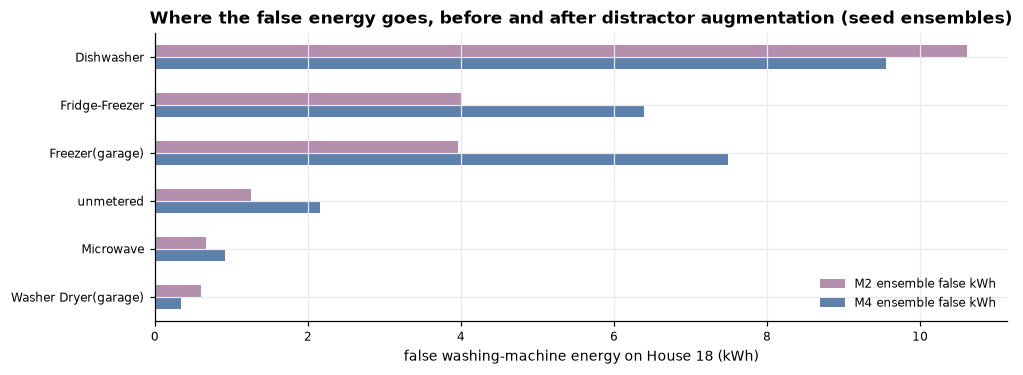

In [8]:
fp4 = (ens4 - y_val.fillna(0)).clip(lower=0).dropna()
fp4 = fp4[fp4 > 20]
o4 = raw.loc[fp4.index, others]
lead4 = o4.idxmax(axis=1).where(o4.max(axis=1) > 100, "unmetered")
attrib4 = fp4.groupby(lead4.map(lambda c: names.get(c, c))).sum() / 60_000
attrib2 = fp.groupby(lead.map(lambda c: names.get(c, c))).sum() / 60_000
att = pd.DataFrame({"M2 ensemble false kWh": attrib2, "M4 ensemble false kWh": attrib4}).fillna(0).sort_values("M2 ensemble false kWh", ascending=False).round(2)
att.to_csv(C.TABLE_DIR / "nb05b_false_energy_m2_vs_m4_val.csv")
SUMMARY["false_kwh_by_appliance_val"] = att.to_dict()
fig, ax = plt.subplots(figsize=(10, 3.4))
att.head(6).plot.barh(ax=ax, color=[P["alt2"], P["pred"]])
ax.invert_yaxis()
ax.set_xlabel("false washing-machine energy on House 18 (kWh)")
ax.set_title("Where the false energy goes, before and after distractor augmentation (seed ensembles)")
plots.save(fig, "nb05b_false_energy_by_appliance")
plt.show()

In [9]:
with open(C.METRIC_DIR / "nb05b_summary.json", "w") as fh:
    json.dump(SUMMARY, fh, indent=2, default=str)

## Summary

**Diagnosis (validation house only).** Seq2Point's false washing-machine energy on House 18 is
22 kWh against 36 kWh of true washing-machine energy. Half of it (48 %) occurs while the
**dishwasher** runs: it heats water at ~2 kW and runs a programme of similar length. About a third
is low-level ghost power during quiet periods, when a fridge or freezer is the largest load. The
garage washer-dryer contributes only 3 %.

**Cheap remedies.**
* The **seed ensemble** (mean of the three Seq2Point seeds) improves validation NDE from 0.68 to
  0.60 and cycle F1 from 0.60 to 0.64 at no training cost. It is kept.
* The **activation filter** (zero any predicted power outside predicted cycles of ≥ 30 min) cuts
  false energy from ~95 % to ~15 % of the true energy and doubles minute-level precision, but
  deletes about half of the true energy too. It is a reporting option for cycle counting, not a
  general fix.

**Distractor augmentation (M4).** Activation banks from the training period only: 4,232
dishwasher, 1,833 tumble-dryer, 275 washer-dryer and 10,941 kettle activations, plus 2,284
washing-machine activations. Two settings were compared at seed 42; "distractors + WM" won on
NDE by 0.001 (0.692 vs 0.693, effectively a tie) and was trained with two more seeds.

| validation, mean of 3 seeds | Seq2Point (M2) | augmented (M4) |
|---|---|---|
| NDE | 0.675 ± 0.051 | **0.614** ± 0.076 |
| cycle F1 | **0.603** ± 0.016 | 0.569 ± 0.081 |
| recall (minutes) / cycle recall | 0.79 / 0.71 | **0.88 / 0.82** |
| true energy recovered | 61 % | **67 %** |
| extra (false) energy | **98 %** | 168 % |
| SAE (total energy error) | **0.59** | 1.35 |

**Decision by the rule fixed before training: not accepted.** NDE improved by 0.061 (more than the
0.051 required) but cycle F1 fell by 0.034 instead of rising by 0.016. M4 finds more of the real
washing (higher recall and recovered energy) but predicts considerably more false energy; dishwasher
false energy fell only from 10.6 to 9.6 kWh, while compressor-time ghost power rose. The most likely
reason is the washing-machine insertions: they raise how often the model sees "washing" during
training, which pushes it towards predicting washing. A distractors-only model, trained with three
seeds, is the natural next experiment; I did not run it here, because choosing a second variant
after seeing this result on the same validation house would no longer be a clean test.

**Primary model for the test homes: the M2 Seq2Point seed ensemble**, fixed here, before
notebook 06 is run. M4 and its ensemble are still scored in notebook 06 for transparency.